# Sparse Primitive Flow Composition Demo

This demo runs the simplified PrimitiveFlow method: normal denoising steps use the full target prompt `P`; selected timesteps aggregate source `S0`, primitive prompts `S1...Sk`, and `P`; LTP uses `P` as the reference. No VQA, reward model, external judge, training, or fine-tuning is used.

In [109]:
GITHUB_REPO_URL = "https://github.com/Soobiwan/aim-flow.git"
HF_TOKEN = ""
PROMPT_SECTION = "primitive_flow_prompts"
PROMPT_KEY = "reflection_shadow_fox"
OUTPUT_DIR = "/kaggle/working/primitive_flow_outputs/reflection_shadow_fox"

In [110]:
%cd /kaggle/working

!rm -rf /kaggle/working/aim-flow
!git clone {GITHUB_REPO_URL} /kaggle/working/aim-flow

%cd /kaggle/working/aim-flow

/kaggle/working
Cloning into '/kaggle/working/aim-flow'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 153 (delta 74), reused 116 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 79.27 KiB | 5.66 MiB/s, done.
Resolving deltas: 100% (74/74), done.
/kaggle/working/aim-flow


In [111]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install --no-cache-dir --force-reinstall torch==2.4.1+cu118 --index-url https://download.pytorch.org/whl/cu118
# !pip install -r requirements-kaggle.txt

In [112]:
from kaggle_secrets import UserSecretsClient
import os

if not HF_TOKEN:
    HF_TOKEN = UserSecretsClient().get_secret("Huggingface")
os.environ["HF_TOKEN"] = HF_TOKEN

In [113]:
import torch, diffusers, transformers
print("torch", torch.__version__)
print("diffusers", diffusers.__version__)
print("transformers", transformers.__version__)
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("GPU", props.name)
    print("VRAM GB", round(props.total_memory / 1024**3, 2))
else:
    print("CUDA not available")

torch 2.10.0+cu128
diffusers 0.36.0
transformers 5.0.0
GPU Tesla P100-PCIE-16GB
VRAM GB 15.89


In [114]:
!python scripts/run_compare.py \
  --config configs/sd3_medium_kaggle.yaml \
  --prompts configs/sample_prompts.yaml \
  --prompt-section {PROMPT_SECTION} \
  --prompt-key {PROMPT_KEY} \
  --output-dir {OUTPUT_DIR}_final_only \
  --modes base source_only primitive_flow_final_only \
  --width 1024 \
  --final-only


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading weights:   0%|                                  | 0/517 [00:00<?, ?it/s]
Loading weights:   0%| | 1/517 [00:00<00:00, 4675.92it/s, Materializing param=te
Loading weights:   0%| | 1/517 [00:00<00:01, 454.13it/s, Materializing param=tex
Loading weights:   0%| | 2/517 [00:00<00:00, 613.61it/s, Materializing param=tex
Loading weights:   0%| | 2/517 [00:00<00:01, 382.87it/s, Materializing param=tex
Loading weights:   1%| | 3/517 [00:00<00:01, 432.21it/s, Materializing param=tex
Loading weights:   1%| | 3/517 [00:00<00:01, 343.38it/s, Materializing param=tex
Loading weights:   1%| | 4/517 [00:00<00:01, 414.67it/s, Materializing param=tex
Loading weights:   1%| | 4/517 [00:00<00:01, 351.81it/

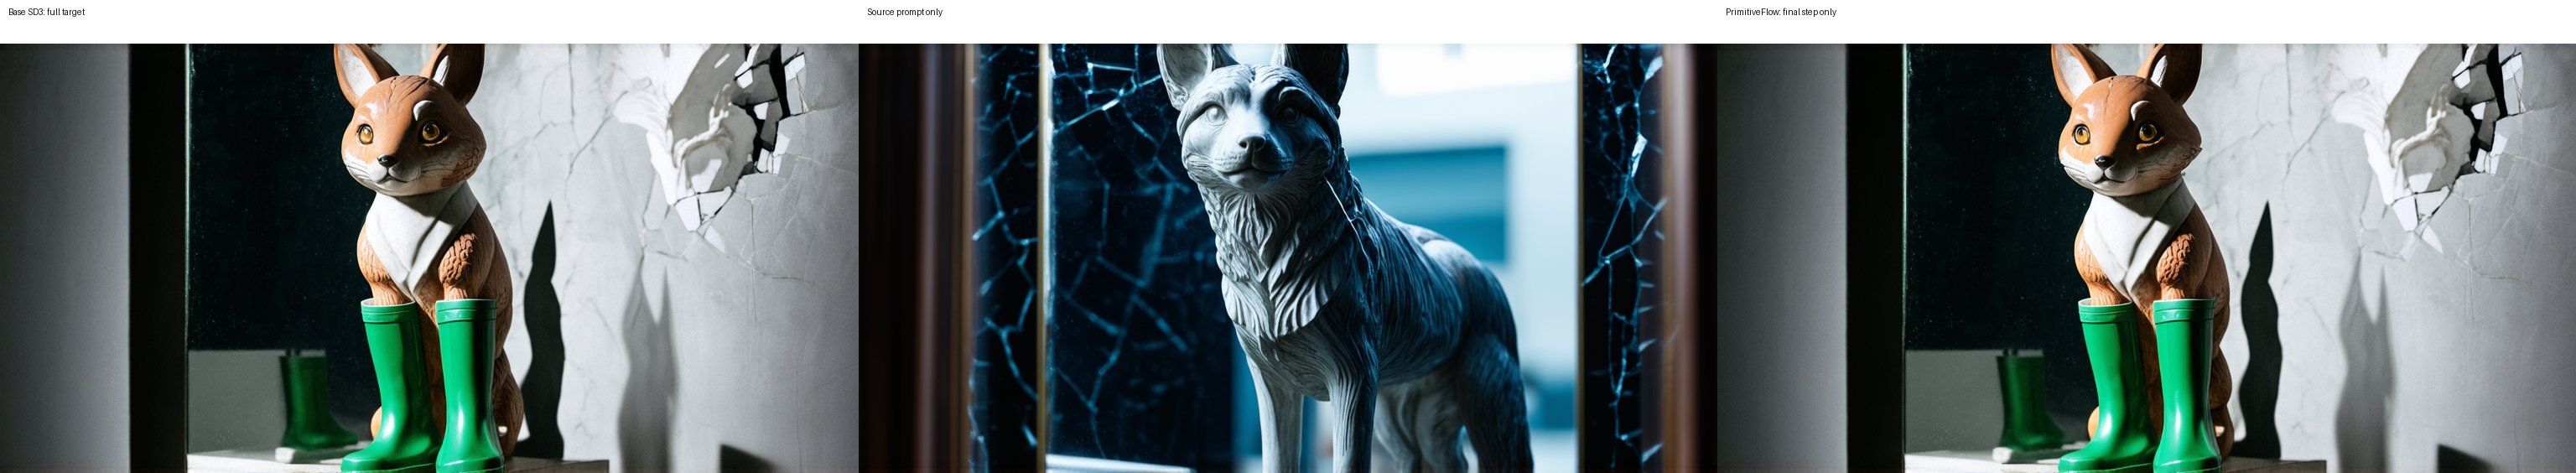

In [115]:
from IPython.display import Image, display
display(Image(filename=f"{OUTPUT_DIR}_final_only/comparison_grid.png"))

In [116]:
!python scripts/run_compare.py \
  --config configs/sd3_medium_kaggle.yaml \
  --prompts configs/sample_prompts.yaml \
  --prompt-section {PROMPT_SECTION} \
  --prompt-key {PROMPT_KEY} \
  --output-dir {OUTPUT_DIR}_sparse \
  --width 1024 \
  --modes base source_only primitive_flow_sparse \
  --aggregation-steps 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 23 24

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading weights:   0%|                                  | 0/197 [00:00<?, ?it/s]
Loading weights:   1%| | 1/197 [00:00<00:00, 891.46it/s, Materializing param=tex
Loading weights:   1%| | 1/197 [00:00<00:00, 471.85it/s, Materializing param=tex
Loading weights:   1%| | 2/197 [00:00<00:00, 505.12it/s, Materializing param=tex
Loading weights:   1%| | 2/197 [00:00<00:00, 368.57it/s, Materializing param=tex
Loading weights:   2%| | 3/197 [00:00<00:00, 398.99it/s, Materializing param=tex
Loading weights:   2%| | 3/197 [00:00<00:00, 352.50it/s, Materializing param=tex
Loading weights:   2%| | 4/197 [00:00<00:00, 343.42it/s, Materializing param=tex
Loading weights:   2%| | 4/197 [00:00<00:00, 310.45it/

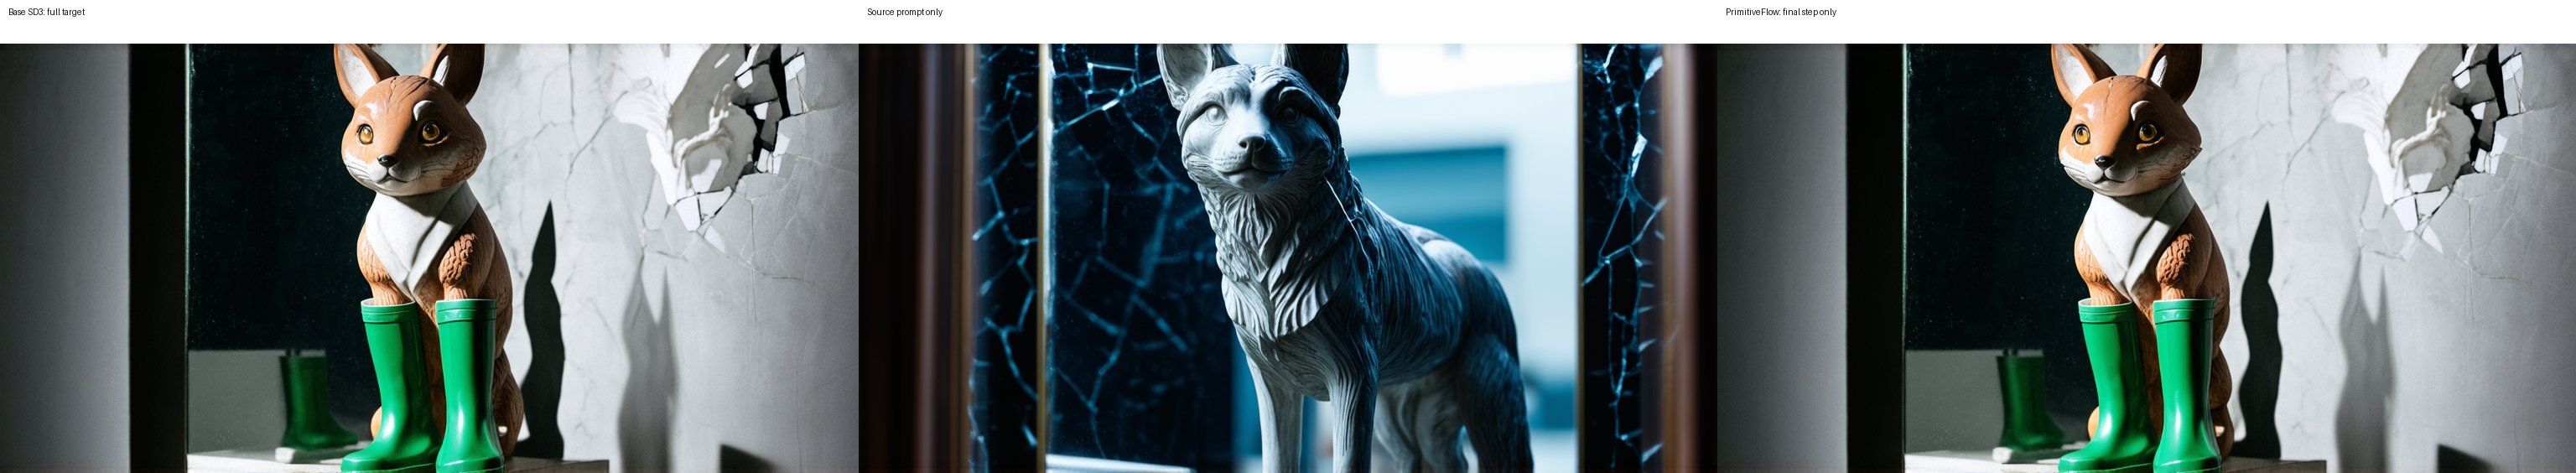

In [117]:
from IPython.display import Image, display
display(Image(filename=f"{OUTPUT_DIR}_final_only/comparison_grid.png"))

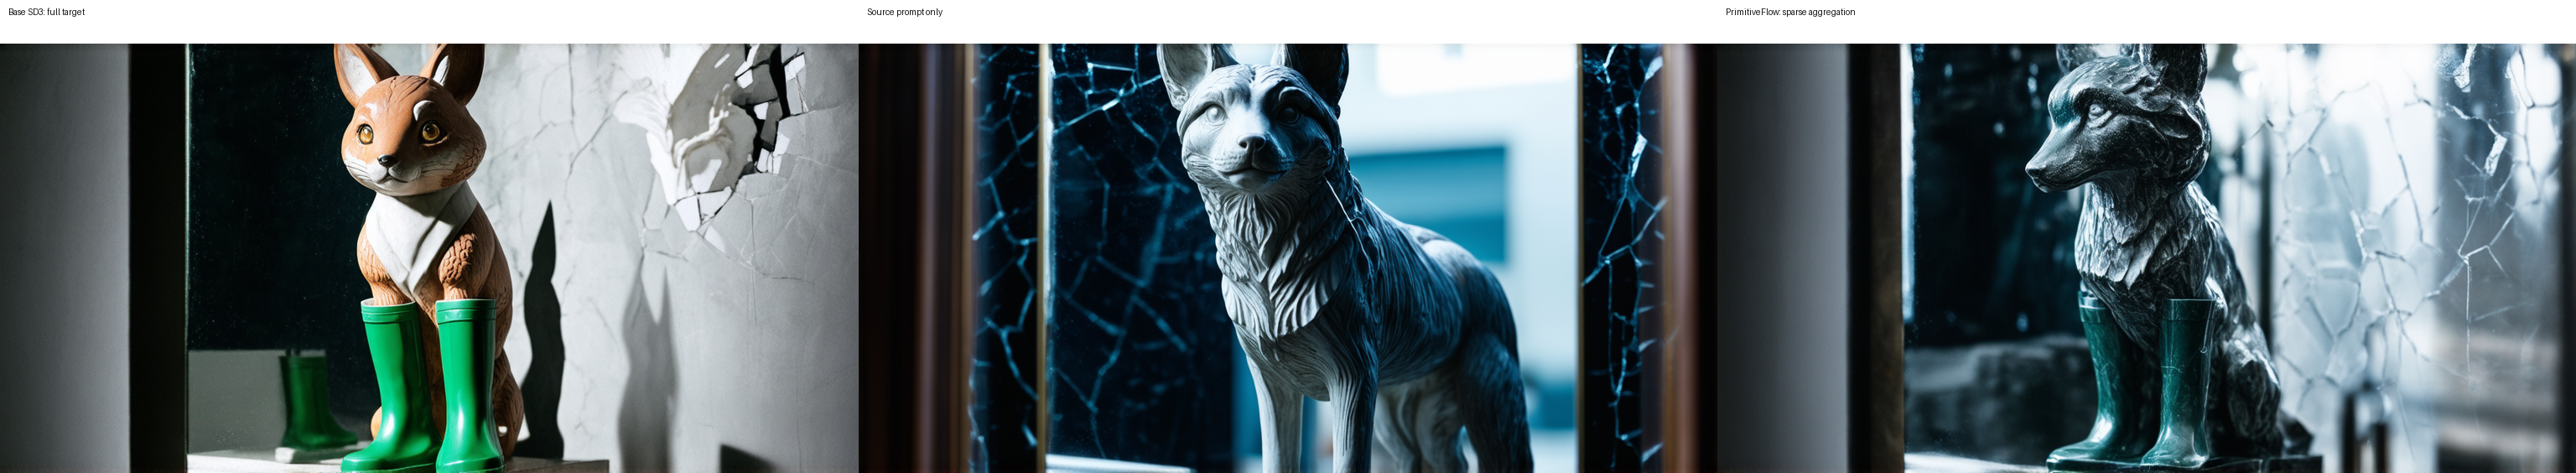

In [118]:
from IPython.display import Image, display
display(Image(filename=f"{OUTPUT_DIR}_sparse/comparison_grid.png"))

In [119]:
import json
metadata_path = f"{OUTPUT_DIR}_sparse/metadata_primitive_flow_sparse.json"
with open(metadata_path) as f:
    meta = json.load(f)
print("target:", meta["target_prompt"])
print("source:", meta["source_prompt"])
print("primitives:", [p["text"] for p in meta["primitive_prompts"]])
print("aggregation_steps:", meta["aggregation_steps"])
print("ltp_mode:", meta["ltp_mode"])
print("fallback:", any(step.get("ltp_fallback") for step in meta["debug_steps"] if step.get("do_aggregate")))
for step in meta["debug_steps"]:
    if step.get("do_aggregate"):
        print(step["step_index"], step.get("softmax_weights"))

target: A marble statue of a fox wearing green rain boots standing in front of a cracked mirror, with its shadow forming the shape of a dragon on the wall, cinematic lighting, realistic photo, sharp focus
source: A marble statue of a fox standing in front of a cracked mirror, cinematic lighting, realistic photo, sharp focus
primitives: ['A marble statue of a fox standing in front of a wall, cinematic lighting, realistic photo, sharp focus', 'A fox statue wearing green rain boots, cinematic lighting, realistic photo, sharp focus', 'A marble fox statue reflected in a mirror perfectly, cinematic lighting, realistic photo, sharp focus', 'A marble fox statue reflected in a cracked mirror with multiple veins of cracks, cinematic lighting, realistic photo, sharp focus', 'The shadow of a fox statue forms on a wall opposite the cracked mirror, cinematic lighting, realistic photo, sharp focus', 'The shadow of a dragon on the wall opposite the cracked mirror, cinematic lighting, realistic photo, 

## Troubleshooting

- Reduce size: `--height 384 --width 384`
- Reduce steps: `--num-inference-steps 16`
- Use velocity LTP: `--ltp-mode velocity`
- Reduce primitives: `--max-primitives 2`
- Try final-only first: `--final-only`
- For 16 steps, try aggregation steps `8 12 15`